### How to use this notebook

This notebook analyzes the stock performance of four major listed AI-era tech companies (Google, Meta, Microsoft and NVIDIA) from 2016 to 2026. It is open for anyone accessing this repository to use and reproduce.

**Needed:**
- Python 3 with Jupyter Notebook
- The following packages: pandas, matplotlib, seaborn, openai (install with `pip install pandas matplotlib seaborn openai`)
- Ollama installed and running locally (note: Ollama is only required for the LLM integration cell, all other cells run without i)
    - Ollama can be downloaded at [ollama.com](https://ollama.com)) 
- The gemma3:4b model pulled in Ollama (run `ollama pull gemma3:4b` in terminal)

**Data:**
All data files are available in the `project/data/` folder in this repository. Download the full repository and keep the folder structure intact.

**Running the notebook:**
1. Make sure all installations and downloads have been made and Ollama is running (`ollama serve` in local terminal)
2. Open the notebook in Jupyter
3. Go to Kernel > Restart & Run All to run all cells from top to bottom

# Stock Performance in the New Era of Artificial Intelligence

In this project I analyze how the stocks of four leading listed AI-era tech companies – Google, Microsoft, Meta and NVIDIA – have performed over the last decade. These four companies were chosen as they represent some of the core players in the generative AI race: NVIDIA supplying the infrastructure, Microsoft and Google competing in AI-powered productivity and search, and Meta building open-source AI into its social platforms. 

The dataset covers the period from 2016 to 2026 and includes daily trading data such as open price, close price, high price, low price, adjusted close price and trading volume for each company. 



## Research Question
What stock has performed the best among these four leading listed AI-era tech companies between 2016 
and 2026?

![Data pipeline](pipeline.png)

In [1]:
# setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Data loading

In [2]:
nvda = pd.read_csv("data/NVDA.csv") # loading stock data into a pandas dataframe
nvda["company"] = "NVIDIA" # adding a company name column for identification

goog = pd.read_csv("data/GOOG.csv")
goog["company"] = "Google"

meta = pd.read_csv("data/META.csv")
meta["company"] = "Meta"

msft = pd.read_csv("data/MSFT.csv")
msft["company"] = "Microsoft"

combined = pd.concat([nvda, goog, meta, msft]) # combining the four dataframe into one to make the analysis easier
combined.head() # displaying the 5 first rows of the combined dataset

,Date,open,high,low,close,adjclose,volume,ingested_at_utc,company
0,2016-01-04,0.80725,0.81450,0.80100,0.80925,0.789545,358076000,2026-05-07 06:29:17.272260+00:00,NVIDIA
1,2016-01-05,0.82450,0.83600,0.81250,0.82225,0.802228,490272000,2026-05-07 06:29:17.272260+00:00,NVIDIA
2,2016-01-06,0.80875,0.81250,0.77900,0.78825,0.769056,449344000,2026-05-07 06:29:17.272260+00:00,NVIDIA
3,2016-01-07,0.76850,0.77375,0.74700,0.75700,0.738567,645304000,2026-05-07 06:29:17.272260+00:00,NVIDIA
4,2016-01-08,0.76675,0.76750,0.73925,0.74075,0.722713,398472000,2026-05-07 06:29:17.272260+00:00,NVIDIA


In [19]:
# exporting and saving the combined dataset as a .csv file to the repository
combined.to_csv("data/combined_dataset.csv", index=False) 

df_check = pd.read_csv("data/combined_dataset.csv") # reloding to check that it saved correctly
display(df_check.head())

,Date,open,high,low,close,adjclose,volume,company,adjclose_normalized,daily_return
0,2016-01-04,0.80725,0.81450,0.80100,0.80925,0.789545,358076000,NVIDIA,100.000000,NaN
1,2016-01-05,0.82450,0.83600,0.81250,0.82225,0.802228,490272000,NVIDIA,101.606410,0.016064
2,2016-01-06,0.80875,0.81250,0.77900,0.78825,0.769056,449344000,NVIDIA,97.405017,-0.041350
3,2016-01-07,0.76850,0.77375,0.74700,0.75700,0.738567,645304000,NVIDIA,93.543408,-0.039645
4,2016-01-08,0.76675,0.76750,0.73925,0.74075,0.722713,398472000,NVIDIA,91.535370,-0.021466


In [4]:
# Alternatively, load the pre-saved combined dataset directly by removing the # mark:
# combined = pd.read_csv("data/combined_dataset.csv")

### Data cleaning

In [5]:
# starting by doing some exploratory data analysis (EDA) by inspecting the data for structure, data types and missing values before cleaning

print("Shape:", combined.shape) #
print("Duplicates:", combined.duplicated().sum())
print()
print("Info:")
print(combined.info())
print()
print("Missing values:")
print(combined.isna().sum())

Shape: (10400, 9)
Duplicates: 0

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 10400 entries, 0 to 2599
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             10400 non-null  object 
 1   open             10400 non-null  float64
 2   high             10400 non-null  float64
 3   low              10400 non-null  float64
 4   close            10400 non-null  float64
 5   adjclose         10400 non-null  float64
 6   volume           10400 non-null  int64  
 7   ingested_at_utc  10400 non-null  object 
 8   company          10400 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 812.5+ KB
None

Missing values:
Date               0
open               0
high               0
low                0
close              0
adjclose           0
volume             0
ingested_at_utc    0
company            0
dtype: int64


In [6]:
# let's clean the data

combined = combined.drop(columns=["ingested_at_utc"], errors="ignore") # dropping column ingested_at_utc, it's the ETL timestamp and not needed for the analysis since we already have trading date value

combined["Date"] = pd.to_datetime(combined["Date"]) # converting date to datetime so it can be used for plotting and calculations

print("Shape after dropping column:", combined.shape)
display(combined.head())

# exporting and saving the cleaned dataset as a .csv file to the repository
combined.to_csv("data/cleaned_dataset.csv", index=False)


Shape after dropping column: (10400, 8)


,Date,open,high,low,close,adjclose,volume,company
0,2016-01-04,0.80725,0.81450,0.80100,0.80925,0.789545,358076000,NVIDIA
1,2016-01-05,0.82450,0.83600,0.81250,0.82225,0.802228,490272000,NVIDIA
2,2016-01-06,0.80875,0.81250,0.77900,0.78825,0.769056,449344000,NVIDIA
3,2016-01-07,0.76850,0.77375,0.74700,0.75700,0.738567,645304000,NVIDIA
4,2016-01-08,0.76675,0.76750,0.73925,0.74075,0.722713,398472000,NVIDIA


### Analysis
In this section, I'm analysing the stock performance of the four companies across three dimensions: price trends over time, normalized performance comparison and volatility.


#### Visual analysis

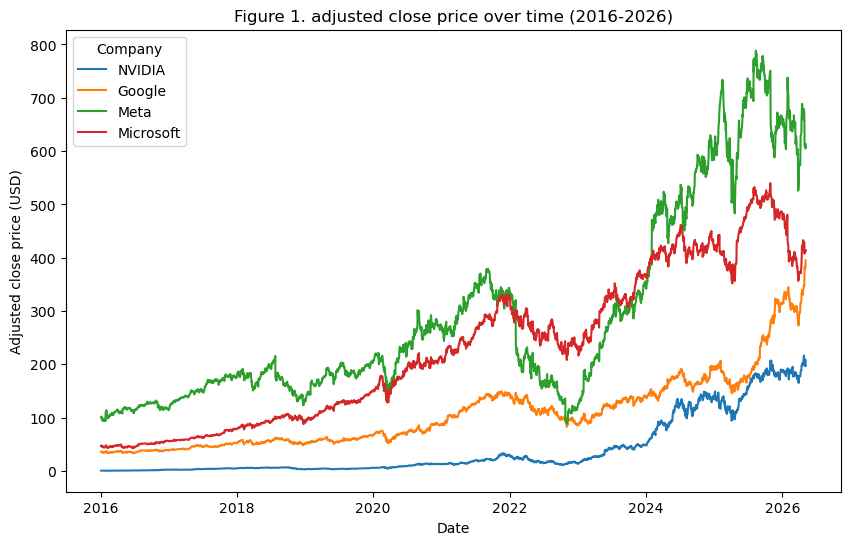

In [7]:
# starting by plotting the adjusted close price over time for all four companies
    # the adjusted close price `adjclose` of a stock is modified to also include corporate actions such as dividends and stock splits, and is hence a better measure for analysing historical performance. 

plt.figure(figsize=(10, 6))
sns.lineplot(data=combined, x="Date", y="adjclose", hue="company")
plt.title("Figure 1. adjusted close price over time (2016-2026)")
plt.xlabel("Date")
plt.ylabel("Adjusted close price (USD)")
plt.legend(title="Company")
plt.show()

Figure 1. shows the adjusted close price for all four companies over the period 2016-2026. Meta dominates in absolute price terms, while NVIDIA appears flat near zero despite its extraordinary growth due to its very low starting price in 2016, making the normalized chart in Figure 2. essential for fair comparison.

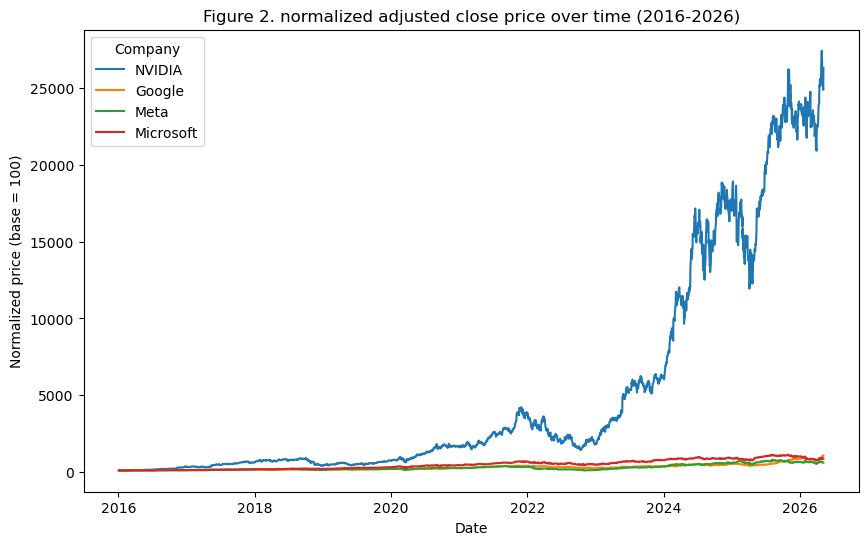

In [8]:
# normalizing the adjusted close price to 100 at the start date to allow fair comparison across companies, since each stock started at a different price level in 2016
combined["adjclose_normalized"] = combined.groupby("company")["adjclose"].transform(lambda x: (x / x.iloc[0]) * 100)

# plotting the normalized adjusted close price over time for all four companies
plt.figure(figsize=(10, 6))
sns.lineplot(data=combined, x="Date", y="adjclose_normalized", hue="company")
plt.title("Figure 2. normalized adjusted close price over time (2016-2026)")
plt.xlabel("Date")
plt.ylabel("Normalized price (base = 100)")
plt.legend(title="Company")
plt.show()

Figure 2. shows the normalized adjusted close price for all four companies, revealing NVIDIA's extraordinary growth of over 25,000 compared to a base of 100 in 2016. The other three companies appear flat in comparison, which is why Figure 3. excludes NVIDIA to show their performance more clearly.

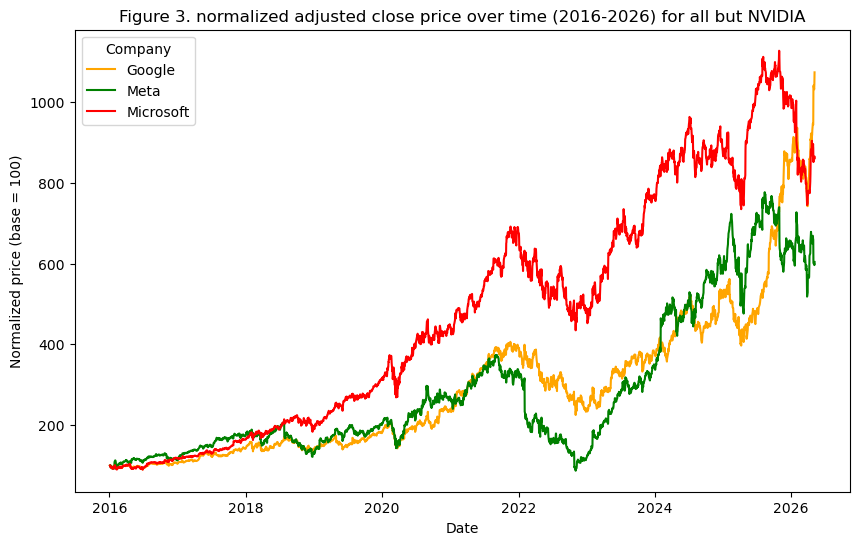

In [9]:
# dropping NVIDIA to get a better look at the progression of the other stocks
combined_no_nvidia = combined[combined["company"] != "NVIDIA"] # 'combined["company"] != "NVIDIA"' keeps all rows where the company is not NVIDIA

# plotting the normalized adjusted close price over time for Google, Meta and Microsoft
plt.figure(figsize=(10, 6))
palette = {"Google": "orange", "Meta": "green", "Microsoft": "red"} # making sure each company has the same colored line as before
sns.lineplot(data=combined_no_nvidia, x="Date", y="adjclose_normalized", hue="company", palette=palette)
plt.title("Figure 3. normalized adjusted close price over time (2016-2026) for all but NVIDIA")
plt.xlabel("Date")
plt.ylabel("Normalized price (base = 100)")
plt.legend(title="Company")
plt.show()

Figure 3. shows the normalized performance excluding NVIDIA, revealing that Microsoft has outperformed Google and Meta over the period, and that all three companies show a notable dip around 2022 followed by a strong recovery towards 2026.

#### Quantitative analysis

In [10]:
# calculating the daily percentage return for each stock

combined["daily_return"] = combined.groupby("company")["adjclose"].transform("pct_change") # .pct_change calculates (today's price - yesterday's price) / yesterday's price for each trading day
combined.head() # checking that the new column appears correctly

,Date,open,high,low,close,adjclose,volume,company,adjclose_normalized,daily_return
0,2016-01-04,0.80725,0.81450,0.80100,0.80925,0.789545,358076000,NVIDIA,100.000000,NaN
1,2016-01-05,0.82450,0.83600,0.81250,0.82225,0.802228,490272000,NVIDIA,101.606410,0.016064
2,2016-01-06,0.80875,0.81250,0.77900,0.78825,0.769056,449344000,NVIDIA,97.405017,-0.041350
3,2016-01-07,0.76850,0.77375,0.74700,0.75700,0.738567,645304000,NVIDIA,93.543408,-0.039645
4,2016-01-08,0.76675,0.76750,0.73925,0.74075,0.722713,398472000,NVIDIA,91.535370,-0.021466


In [11]:
# calculating the volatility (standard deviation) of return for each stock

volatility = combined.groupby("company")["daily_return"].std()
print("Standard deviation of daily returns per company:")
print()
print((volatility * 100).round(2).astype(str).add("%").to_string()) # converts from numbers to text and adds percentage sign, rounds to 2 decimals, adds % sign and removes unnecessary clutter

Standard deviation of daily returns per company:

company
Google       1.82%
Meta         2.43%
Microsoft     1.7%
NVIDIA       3.12%


In [12]:
# calculating the average daily return for each stock

avg_return = combined.groupby("company")["daily_return"].mean() # groups by company and calculates the average daily return for each one
print("Average daily return per company:")
print()
print((avg_return * 100).round(3).astype(str).add("%").to_string())  # converts from numbers to text and adds percentage sign, rounds to 3 decimals, adds % sign and removes unnecessary clutter

Average daily return per company:

company
Google       0.108%
Meta         0.099%
Microsoft    0.097%
NVIDIA       0.263%


In [13]:
# calculating the total return for each stock over the full period

first_price = combined.groupby("company")["adjclose"].first() # retrieves the very first adjusted close price for each company
last_price = combined.groupby("company")["adjclose"].last() # retrieves the very last adjusted close price for each company
total_return = ((last_price - first_price) / first_price * 100).round(2) # total return formula

print("Total return per company (2016-2026):")
print()
print(total_return.astype(str).add("%").to_string())

Total return per company (2016-2026):

company
Google         974.04%
Meta           504.27%
Microsoft      764.68%
NVIDIA       26222.75%


In [14]:
# building a summary statistics table combining total return, average daily return and volatility

summary = pd.DataFrame({ # creates a new dataframe
    "Total Return (%)": total_return,
    "Avg Daily Return (%)": (avg_return * 100).round(3),
    "Volatility (%)": (volatility * 100).round(2)
})

display(summary) # displaying sumamry statistics

,Total Return (%),Avg Daily Return (%),Volatility (%)
company,,,
Google,974.04,0.108,1.82
Meta,504.27,0.099,2.43
Microsoft,764.68,0.097,1.70
NVIDIA,26222.75,0.263,3.12


The summary table confirms NVIDIA as the clear outperformer across all metrics, while Microsoft offers the most stable returns with the lowest volatility of the four companies.

In [15]:
# exporting and saving the summary statistics dataset as a .csv file to the repository
summary.to_csv("data/summary.csv", index=False)

#### LLM integration

The following section uses a local LLM (Gemma3 via Ollama) to provide an analyst commentary based on the key findings from the quantitative analysis.

In [16]:
# installing and importing the required libraries for the LLM integration
!pip install openai -q

from openai import OpenAI

# connecting to the local Ollama server
client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)
MODEL = "gemma3:4b"

# creating a helper function to send a prompt to the LLM and return the response as text
def ask_llm(prompt):
    """Send a prompt to the local Ollama LLM and return the response text."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

In [17]:
# asking the LLM to analyze the stock performance findings

prompt = f"""You are a financial analyst. Below are the stock performance statistics for four listed major AI-era tech companies from 2016 to 2026.

Google:    Total return: 974.04%,  Avg daily return: 0.108%,  Volatility: 1.82%
Meta:      Total return: 504.27%,  Avg daily return: 0.099%,  Volatility: 2.43%
Microsoft: Total return: 764.68%,  Avg daily return: 0.097%,  Volatility: 1.70%
NVIDIA:    Total return: 26222.75%, Avg daily return: 0.263%, Volatility: 3.12%

Write a short analyst commentary (with a maximum of 3 sentences) summarizing which stock performed best, the relationship between risk and return, and what these results suggest about the AI boom. Write in plain English suitable for a business audience."""

print(ask_llm(prompt))

Here's a short analyst commentary based on the provided data:

“NVIDIA has overwhelmingly outperformed the other companies, achieving a massive 26222.75% total return, highlighting the extraordinary growth potential within the AI chip sector.  Notably, higher volatility (3.12%) was consistently associated with greater returns, demonstrating the inherent risk-reward relationship of investing in this rapidly evolving technology. These results strongly suggest that investments in AI-related companies, particularly those heavily involved in hardware acceleration, are currently generating exceptional returns driven by the ongoing AI boom.”


In [18]:
# another prompt

prompt2 = f"""You are a financial analyst. Below are the stock performance statistics for four listed major AI-era tech companies from 2016 to 2026.

Google:    Total return: 974.04%,  Avg daily return: 0.108%,  Volatility: 1.82%
Meta:      Total return: 504.27%,  Avg daily return: 0.099%,  Volatility: 2.43%
Microsoft: Total return: 764.68%,  Avg daily return: 0.097%,  Volatility: 1.70%
NVIDIA:    Total return: 26222.75%, Avg daily return: 0.263%, Volatility: 3.12%

Based on these results, which company would you recommend to a risk-averse investor and which to a risk-tolerant investor, and why?
Answer with a maximum of 3 sentences."""

print(ask_llm(prompt2))

For a risk-averse investor, I’d recommend **Microsoft**, exhibiting the lowest volatility (1.70%) and a relatively stable average daily return (0.097%) over the period. Conversely, for a risk-tolerant investor seeking potentially high returns, **NVIDIA** presents the most compelling option, boasting the highest total return (26222.75%) and a notably higher daily volatility (0.263%) reflecting its aggressive growth trajectory.


## Conclusion

NVIDIA has overwhelmingly outperformed the other three companies over the period 2016 to 2026, 
achieving a total return of 26,222%, meaning that €100 invested in NVIDIA in 2016 would be worth 
approximately €26,200 today. This extraordinary performance is closely linked to NVIDIA's dominant 
position as the primary supplier of GPUs powering the AI boom, particularly accelerating from 2023 
onwards. However, NVIDIA also carries the highest risk with a daily volatility of 3.12%, illustrating 
the classic relationship between risk and return. Among the remaining three companies, Google performed 
best with a total return of 974%, followed by Microsoft at 765% and Meta at 504%. Overall, all four 
companies delivered strong returns over the decade, reflecting their central roles in the AI era and 
their resilience through events such as the COVID-19 pandemic.

### Statement of AI use

I used Claude Sonnet 4.6 throughout this project to help me troubleshoot errors, closely examine what my code does, and improve some of my comments and markdown text (regarding spelling errors and grammars). All code was written by me and all analytical decisions were my own.